# Notebook 2 — Depth Anything 3 Metric (DA3METRIC-LARGE)

Loads pretrained `DA3METRIC-LARGE`, evaluates against iPhone LiDAR ground truth from Record3D `.r3d` captures, and fits a two-parameter affine calibration in **disparity (inverse-depth) space** that `fusion_server.py` reads from `calibration.json`.

**No fine-tuning.** DA3METRIC-LARGE is 0.35B params and full fine-tuning is impractical on Colab. The standard workflow is pretrained inference + a small calibration per device — that's what this notebook does, and the LiDAR data shows it's enough. Because the weights are unchanged, only `calibration.json` is exported; `fusion_server.py` pulls DA3 directly from HuggingFace.

**Why disparity-space:** monocular depth bias is approximately linear in `1/depth`, not in depth. A single scalar `s` (the old approach) can't fit both near and far simultaneously — it under-corrects close range or over-corrects far range. Fitting `1/gt ≈ a · (1/raw) + b` and applying `depth_corrected = 1/(a/raw + b)` is the same data, the same fit complexity, but tracks the actual error curve.

**Output unit:** DA3METRIC outputs depth in **meters directly** — no `fx`-based formula. (The `fx * net / 300` formula in the DA3 README is for the *relative* variant, not the metric one.)

In [1]:
%cd /content
# DA3's pyproject pins numpy<2 which breaks Colab's prebuilt scipy/torch ABI.
# So we sys.path the cloned repo directly (no `pip install -e` → no numpy downgrade)
# and pip-install only the deps DA3 imports that aren't in Colab base.
%pip install -q pyliblzfse addict pillow-heif plyfile pycolmap trimesh evo e3nn

import os, sys, importlib
if not os.path.isdir("/content/da3"):
    !git clone -q https://github.com/ByteDance-Seed/Depth-Anything-3.git /content/da3
sys.path.insert(0, "/content/da3/src")
importlib.invalidate_caches()

import numpy, scipy, torch, depth_anything_3
print(f"numpy={numpy.__version__}  scipy={scipy.__version__}  torch={torch.__version__}")
print(f"DA3 at: {depth_anything_3.__file__}")
!nvidia-smi

/content
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 110.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.1/27.1 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.3/160.3 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 450.7/450.7 kB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.5/139.5 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 13.2 MB/s eta 0:00:00
numpy=2.0.2  scipy=1.16.3  torch=2.10.0+cu128
DA3 at: None
Thu May 21 15:

In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
from pathlib import Path
import zipfile, re

CAPTURES = Path("/content/drive/MyDrive/captures")  # .r3d files (Record3D native, includes LiDAR depth)
WEIGHTS_OUT = Path("/content/drive/MyDrive/weights")
WEIGHTS_OUT.mkdir(parents=True, exist_ok=True)


def _has_frames(p):
    try:
        with zipfile.ZipFile(p) as z:
            return any(re.match(r"rgbd/\d+\.jpg$", n) for n in z.namelist())
    except Exception:
        return False


all_r3d = sorted(CAPTURES.glob("*.r3d"))
r3d_files = [p for p in all_r3d if _has_frames(p)]
skipped = [p for p in all_r3d if p not in r3d_files]
assert r3d_files, f"no valid .r3d files in {CAPTURES} (export with 'Share .r3d' — must include RGBD frames)"
print(f"{len(r3d_files)} valid .r3d files (skipped {len(skipped)} without rgbd frames)")
for p in skipped:
    print(f"  skipped: {p.name}")

32 valid .r3d files (skipped 4 without rgbd frames)
  skipped: 2026-05-21--15-13-33.r3d
  skipped: 2026-05-21--15-14-01.r3d
  skipped: 2026-05-21--15-14-15.r3d
  skipped: 2026-05-21--15-17-20.r3d


## Record3D .r3d loader

`.r3d` is a zip containing per-frame RGB jpegs + LZFSE-compressed float16 depth + a `metadata` JSON with the camera intrinsics. LiDAR depth is 256×192 in meters; we upsample to RGB resolution for evaluation.

In [5]:
import json, zipfile, re
import numpy as np
import cv2
import liblzfse


def _depth_dtype(nbytes, dh, dw):
    """Record3D depth blob is dh*dw values, but dtype varies by device/version
    (float16 on older iPhones, float32 on iPhone 15 Pro/Pro Max)."""
    for dt in (np.float32, np.float16):
        if nbytes == dh * dw * np.dtype(dt).itemsize:
            return dt
    raise ValueError(f"depth blob is {nbytes} bytes, doesn't fit {dh}x{dw} as fp32 or fp16")


def _first_frame_name(z):
    names = sorted(
        [n for n in z.namelist() if re.match(r"rgbd/\d+\.jpg$", n)],
        key=lambda n: int(re.search(r"(\d+)", n).group(1)),
    )
    if not names:
        raise RuntimeError("no rgbd/<i>.jpg frames in archive")
    return names[0]


def load_r3d(r3d_path, max_frames=None, stride=1):
    """Yield (rgb_uint8, depth_meters_float32_upsampled, K_3x3, conf_uint8_upsampled)."""
    with zipfile.ZipFile(r3d_path) as z:
        meta = json.loads(z.read("metadata").decode())
        K = np.array(meta["K"]).reshape(3, 3).T
        dw, dh = int(meta["dw"]), int(meta["dh"])
        rgb_names = sorted(
            [n for n in z.namelist() if re.match(r"rgbd/\d+\.jpg$", n)],
            key=lambda n: int(re.search(r"(\d+)", n).group(1)),
        )

        # Dtype is consistent per capture — detect once on the first frame.
        first_depth_raw = liblzfse.decompress(z.read(rgb_names[0].replace(".jpg", ".depth")))
        depth_dtype = _depth_dtype(len(first_depth_raw), dh, dw)

        n = 0
        for i, name in enumerate(rgb_names):
            if i % stride:
                continue
            rgb = cv2.cvtColor(
                cv2.imdecode(np.frombuffer(z.read(name), np.uint8), cv2.IMREAD_COLOR),
                cv2.COLOR_BGR2RGB,
            )
            H, W = rgb.shape[:2]

            depth_lo = np.frombuffer(
                liblzfse.decompress(z.read(name.replace(".jpg", ".depth"))),
                dtype=depth_dtype,
            ).reshape(dh, dw).astype(np.float32)
            conf_lo = np.frombuffer(
                liblzfse.decompress(z.read(name.replace(".jpg", ".conf"))),
                dtype=np.uint8,
            ).reshape(dh, dw)

            depth = cv2.resize(depth_lo, (W, H), interpolation=cv2.INTER_LINEAR)
            conf = cv2.resize(conf_lo, (W, H), interpolation=cv2.INTER_NEAREST)
            yield rgb, depth, K, conf
            n += 1
            if max_frames and n >= max_frames:
                return


# Diagnostic + smoke test
with zipfile.ZipFile(r3d_files[0]) as _z:
    _meta = json.loads(_z.read("metadata").decode())
    _first = _first_frame_name(_z)
    _draw = liblzfse.decompress(_z.read(_first.replace(".jpg", ".depth")))
_dt = _depth_dtype(len(_draw), _meta["dh"], _meta["dw"])
print(f"first frame: {_first} | metadata dw={_meta['dw']} dh={_meta['dh']} | depth dtype={np.dtype(_dt).name}")

rgb, depth, K, conf = next(load_r3d(r3d_files[0], max_frames=1))
valid = (conf == 2) & np.isfinite(depth) & (depth > 0)
print(f"RGB: {rgb.shape} | depth: {depth.shape} | valid: {valid.sum():,} ({100*valid.mean():.1f}%)")
print(f"depth range on valid: [{depth[valid].min():.2f}, {depth[valid].max():.2f}] m")
print("K:\n", K)

first frame: rgbd/0.jpg | metadata dw=256 dh=192 | depth dtype=float32
RGB: (720, 960, 3) | depth: (720, 960) | valid: 225,959 (32.7%)
depth range on valid: [0.13, 5.64] m
K:
 [[682.20843506   0.         481.49398804]
 [  0.         682.20843506 357.09463501]
 [  0.           0.           1.        ]]


In [6]:
import torch
from depth_anything_3.api import DepthAnything3

device = "cuda"
# Keep model fp32; DA3 uses internal torch.autocast for mixed precision.
# Manual .half() collides with depth-head blocks that disable autocast.
model = DepthAnything3.from_pretrained("depth-anything/DA3METRIC-LARGE").to(device).eval()
n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"DA3METRIC-LARGE loaded: {n_params:.1f}M params")

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':



[WARN ] Dependency `gsplat` is required for rendering 3DGS. Install via: pip install git+https://github.com/nerfstudio-project/gsplat.git@0b4dddf04cb687367602c01196913cde6a743d70


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(



config.json:   0%|          | 0.00/847 [00:00<?, ?B/s]

[INFO ] using MLP layer as FFN


model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

DA3METRIC-LARGE loaded: 334.2M params


## Run DA3 on a single frame and convert to metric meters

In [7]:
import tempfile
from PIL import Image

_DA3_TMP = Path(tempfile.gettempdir()) / "da3_frame.png"


def da3_metric(rgb):
    """Return DA3METRIC depth in meters, same HxW as input rgb."""
    Image.fromarray(rgb).save(_DA3_TMP)
    with torch.no_grad():
        pred = model.inference([str(_DA3_TMP)])
    net = pred.depth[0]
    if isinstance(net, torch.Tensor):
        net = net.float().cpu().numpy()
    if net.shape != rgb.shape[:2]:
        net = cv2.resize(net, (rgb.shape[1], rgb.shape[0]), interpolation=cv2.INTER_LINEAR)
    return net


pred_m = da3_metric(rgb)
print(f"pred depth range: [{pred_m.min():.2f}, {pred_m.max():.2f}] m")

[INFO ] Processed Images Done taking 0.06722617149353027 seconds. Shape:  torch.Size([1, 3, 378, 504])
[INFO ] Model Forward Pass Done. Time: 1.3336167335510254 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0019197463989257812 seconds
pred depth range: [0.20, 2.96] m


## Side-by-side visualization (RGB / LiDAR GT / DA3 pred)

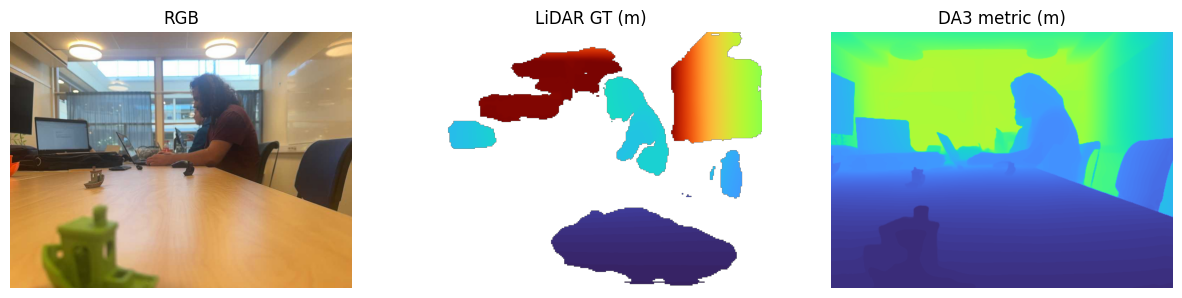

In [8]:
import matplotlib.pyplot as plt


def show_triplet(rgb, gt, pred, conf):
    valid = conf == 2  # 2 = high confidence in Record3D
    vmax = float(np.nanpercentile(gt[valid], 99)) if valid.any() else 5.0
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(rgb)
    ax[0].set_title("RGB")
    ax[0].axis("off")
    ax[1].imshow(np.where(valid, gt, np.nan), vmin=0, vmax=vmax, cmap="turbo")
    ax[1].set_title("LiDAR GT (m)")
    ax[1].axis("off")
    ax[2].imshow(pred, vmin=0, vmax=vmax, cmap="turbo")
    ax[2].set_title("DA3 metric (m)")
    ax[2].axis("off")
    plt.show()


show_triplet(rgb, depth, pred_m, conf)

## Evaluate on a calibration set and fit the disparity-space affine

Pull ~50 frames across captures, compute AbsRel + δ1 against LiDAR (high-confidence pixels only). Then fit the two-parameter affine `1/gt ≈ a·(1/raw) + b` in disparity space — a single scalar can't correct near and far range at once (see the intro), but this tracks the actual error curve with the same data and fit complexity.

In [ ]:
def absrel(pred, gt, mask):
    return float(np.mean(np.abs(pred[mask] - gt[mask]) / np.maximum(gt[mask], 1e-3)))


def delta1(pred, gt, mask, thresh=1.25):
    r = np.maximum(pred[mask] / np.maximum(gt[mask], 1e-3), gt[mask] / np.maximum(pred[mask], 1e-3))
    return float(np.mean(r < thresh))


FRAMES_PER_FILE = 10
STRIDE_FOR_EVAL = 10
MIN_DEPTH, MAX_DEPTH = 0.3, 5.0  # iPhone LiDAR usable range

preds, gts = [], []
for f in r3d_files:
    for rgb_i, gt_i, K_i, conf_i in load_r3d(f, max_frames=FRAMES_PER_FILE, stride=STRIDE_FOR_EVAL):
        p_i = da3_metric(rgb_i)
        mask = (conf_i == 2) & (gt_i > MIN_DEPTH) & (gt_i < MAX_DEPTH)
        if mask.sum() < 1000:
            continue
        preds.append(p_i[mask])
        gts.append(gt_i[mask])

preds_all = np.concatenate(preds)
gts_all = np.concatenate(gts)
all_mask = np.ones_like(preds_all, dtype=bool)
ar = absrel(preds_all, gts_all, all_mask)
d1 = delta1(preds_all, gts_all, all_mask)
print(f"BEFORE calibration: AbsRel={ar:.4f}  delta1={d1:.4f}  (n={len(preds_all):,} px)")

# Affine fit in disparity space: 1/gt ≈ a * (1/pred) + b
disp_pred = 1.0 / np.maximum(preds_all, 1e-3)
disp_gt = 1.0 / np.maximum(gts_all, 1e-3)
a, b = np.polyfit(disp_pred, disp_gt, 1)

calibrated = 1.0 / np.maximum(a * disp_pred + b, 1e-3)
ar2 = absrel(calibrated, gts_all, all_mask)
d1_2 = delta1(calibrated, gts_all, all_mask)
print(f"AFTER  calibration: a={a:.4f} b={b:.4f}  AbsRel={ar2:.4f}  delta1={d1_2:.4f}")

In [ ]:
import json as _json

(WEIGHTS_OUT / "calibration.json").write_text(
    _json.dumps(
        {
            "disparity_a": float(a),
            "disparity_b": float(b),
            "absrel_before": ar,
            "absrel_after": ar2,
            "delta1_before": d1,
            "delta1_after": d1_2,
            "n_pixels": len(preds_all),
            "min_depth_m": MIN_DEPTH,
            "max_depth_m": MAX_DEPTH,
        },
        indent=2,
    )
)
print("saved:", WEIGHTS_OUT / "calibration.json")

## That's it

No weights to export — `DA3METRIC-LARGE` is unchanged, so `fusion_server.py` loads it directly from HuggingFace. Only `calibration.json` crosses the Colab → laptop boundary.

In [ ]:
# Final smoke test: calibrated depth on a held-out frame
rgb_t, depth_t, K_t, conf_t = next(load_r3d(r3d_files[-1], max_frames=1, stride=50))
raw_t = da3_metric(rgb_t)
pred_calibrated = 1.0 / np.maximum(a / np.maximum(raw_t, 1e-3) + b, 1e-3)
show_triplet(rgb_t, depth_t, pred_calibrated, conf_t)
print(f"center pixel: GT={depth_t[depth_t.shape[0]//2, depth_t.shape[1]//2]:.2f} m, "
      f"pred={pred_calibrated[pred_calibrated.shape[0]//2, pred_calibrated.shape[1]//2]:.2f} m")